In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

In [13]:
import pandas as pd

df = pd.read_csv('/dataset.csv')


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
df.columns.tolist()

['Unnamed',
 'X1',
 'X2',
 'X3',
 'X4',
 'X5',
 'X6',
 'X7',
 'X8',
 'X9',
 'X10',
 'X11',
 'X12',
 'X13',
 'X14',
 'X15',
 'X16',
 'X17',
 'X18',
 'X19',
 'X20',
 'X21',
 'X22',
 'X23',
 'X24',
 'X25',
 'X26',
 'X27',
 'X28',
 'X29',
 'X30',
 'X31',
 'X32',
 'X33',
 'X34',
 'X35',
 'X36',
 'X37',
 'X38',
 'X39',
 'X40',
 'X41',
 'X42',
 'X43',
 'X44',
 'X45',
 'X46',
 'X47',
 'X48',
 'X49',
 'X50',
 'X51',
 'X52',
 'X53',
 'X54',
 'X55',
 'X56',
 'X57',
 'X58',
 'X59',
 'X60',
 'X61',
 'X62',
 'X63',
 'X64',
 'X65',
 'X66',
 'X67',
 'X68',
 'X69',
 'X70',
 'X71',
 'X72',
 'X73',
 'X74',
 'X75',
 'X76',
 'X77',
 'X78',
 'X79',
 'X80',
 'X81',
 'X82',
 'X83',
 'X84',
 'X85',
 'X86',
 'X87',
 'X88',
 'X89',
 'X90',
 'X91',
 'X92',
 'X93',
 'X94',
 'X95',
 'X96',
 'X97',
 'X98',
 'X99',
 'X100',
 'X101',
 'X102',
 'X103',
 'X104',
 'X105',
 'X106',
 'X107',
 'X108',
 'X109',
 'X110',
 'X111',
 'X112',
 'X113',
 'X114',
 'X115',
 'X116',
 'X117',
 'X118',
 'X119',
 'X120',
 'X121',
 'X122'

In [16]:
df.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [17]:
df.shape

(11500, 180)

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# --- Step 0: assume df is your pandas DataFrame ---

# Step 1: Select target and convert labels to categorical
target_column = 'y'
X = df.drop(columns=[target_column])
y = df[target_column] - 1               # Convert classes 1–5 to 0–4
y = to_categorical(y, num_classes=5)    # One‑hot

# Step 2: One‑hot encode any non‑numeric (categorical) columns
# This will automatically detect object/category dtypes
X = pd.get_dummies(X, drop_first=True)

# Step 3: Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Step 5: Build Neural Network with L2 regularization
model = Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.001),
          input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(5, activation='softmax')  # 5 classes
])

# Step 6: Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 7: Setup checkpoint callback
checkpoint = ModelCheckpoint(
    filepath='m00.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Now you can train:
# history = model.fit(
#     X_train_scaled, y_train,
#     validation_split=0.2,
#     epochs=50,
#     batch_size=32,
#     callbacks=[checkpoint]
# )


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# Step 7: Train model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[checkpoint]
)

Epoch 1/50
287/288 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2254 - loss: 2.0174
Epoch 1: val_accuracy improved from -inf to 0.38130, saving model to m00.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.2256 - loss: 2.0165 - val_accuracy: 0.3813 - val_loss: 2.0436
Epoch 2/50
287/288 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3646 - loss: 1.8528
Epoch 2: val_accuracy did not improve from 0.38130
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.3648 - loss: 1.8520 - val_accuracy: 0.3752 - val_loss: 1.6565
Epoch 3/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5083 - loss: 1.5049
Epoch 3: val_accuracy did not improve from 0.38130
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5084 - loss: 1.5048 - val_accuracy: 0.3813 - val_loss: 1.6839
Epoch 4/50
287/288 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6926 - loss: 1.1580
Epoch 4: val_accuracy improved from 0.38130 to 0.38696, saving model to m00.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 10s 2

In [24]:
# If you had one-hot encoded before, switch back to just labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Re-encode target as 1D array
y = le.fit_transform(df["y"].values)
X = df.drop(columns=["Unnamed", "y"]).values

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=10,
    eval_metric='Accuracy',
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)
preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))


0:	learn: 0.4130435	test: 0.3995652	best: 0.3995652 (0)	total: 2.74s	remaining: 45m 38s
100:	learn: 0.8635870	test: 0.6600000	best: 0.6600000 (100)	total: 5m 12s	remaining: 46m 23s
200:	learn: 0.9863043	test: 0.6900000	best: 0.6947826 (194)	total: 10m 26s	remaining: 41m 30s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7008695652
bestIteration = 226

Shrink model to first 227 iterations.
Accuracy: 0.7008695652173913


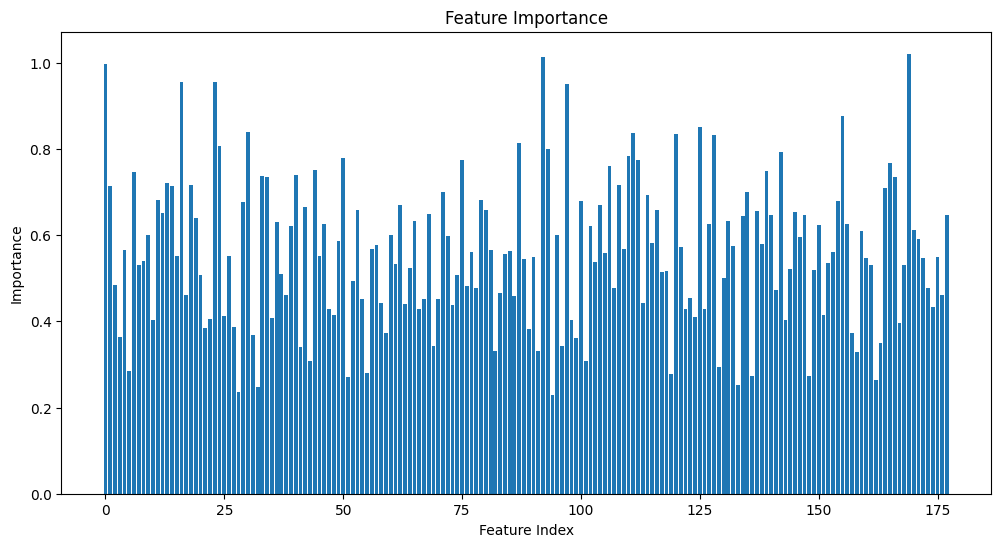

In [26]:
import matplotlib.pyplot as plt

feature_importances = model.get_feature_importance()
plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importances)), feature_importances)
plt.title("Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

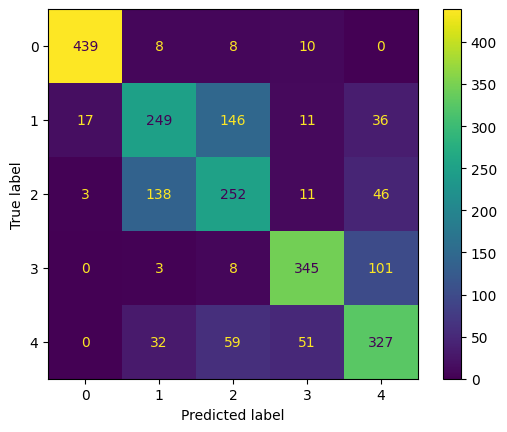

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()



In [28]:
import numpy as np

# Get top N features
N = 100
importances = model.get_feature_importance()
top_indices = np.argsort(importances)[-N:]

# Reduce your dataset to top N features
X_train_top = X_train[:, top_indices]
X_test_top = X_test[:, top_indices]

# Re-train model
model.fit(X_train_top, y_train, eval_set=(X_test_top, y_test), early_stopping_rounds=50)


0:	learn: 0.4108696	test: 0.4056522	best: 0.4056522 (0)	total: 1.51s	remaining: 25m 7s
100:	learn: 0.8650000	test: 0.6560870	best: 0.6573913 (98)	total: 2m 55s	remaining: 25m 57s
200:	learn: 0.9809783	test: 0.6939130	best: 0.6939130 (200)	total: 5m 47s	remaining: 23m 1s
300:	learn: 0.9982609	test: 0.7030435	best: 0.7069565 (271)	total: 8m 43s	remaining: 20m 16s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7069565217
bestIteration = 271

Shrink model to first 272 iterations.


In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model.fit(X_train_pca, y_train, eval_set=(X_test_pca, y_test), early_stopping_rounds=50)


0:	learn: 0.4736957	test: 0.4634783	best: 0.4634783 (0)	total: 1.13s	remaining: 18m 48s
100:	learn: 0.8670652	test: 0.7152174	best: 0.7165217 (93)	total: 1m 27s	remaining: 13m 2s
200:	learn: 0.9797826	test: 0.7439130	best: 0.7465217 (188)	total: 2m 55s	remaining: 11m 37s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7491304348
bestIteration = 205

Shrink model to first 206 iterations.


In [30]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier


In [31]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ('cat', CatBoostClassifier(verbose=0)),
        ('lgb', LGBMClassifier())
    ],
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)
print("Stacked Accuracy:", stack.score(X_test, y_test))


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028557 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 45390
[LightGBM] [Info] Number of data points in the train set: 9200, number of used features: 178
[LightGBM] [Info] Start training from score -1.612159
[LightGBM] [Info] Start training from score -1.608895
[LightGBM] [Info] Start training from score -1.604018
[LightGBM] [Info] Start training from score -1.607809
[LightGBM] [Info] Start training from score -1.614341


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 45390
[LightGBM] [Info] Number of data points in the train set: 7360, number of used features: 178
[LightGBM] [Info] Start training from score -1.612159
[LightGBM] [Info] Start training from score -1.608759
[LightGBM] [Info] Start training from score -1.604018
[LightGBM] [Info] Start training from score -1.608080
[LightGBM] [Info] Start training from score -1.614205


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030195 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 45390
[LightGBM] [Info] Number of data points in the train set: 7360, number of used features: 178
[LightGBM] [Info] Start training from score -1.612159
[LightGBM] [Info] Start training from score -1.608759
[LightGBM] [Info] Start training from score -1.604018
[LightGBM] [Info] Start training from score -1.607402
[LightGBM] [Info] Start training from score -1.614888


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Stacked Accuracy: 0.7408695652173913


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [32]:
target_column = 'y'
pd.set_option('display.max_rows', 100)
print(df[target_column].value_counts(ascending=False))
pd.reset_option('display.max_rows')

y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64


In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns


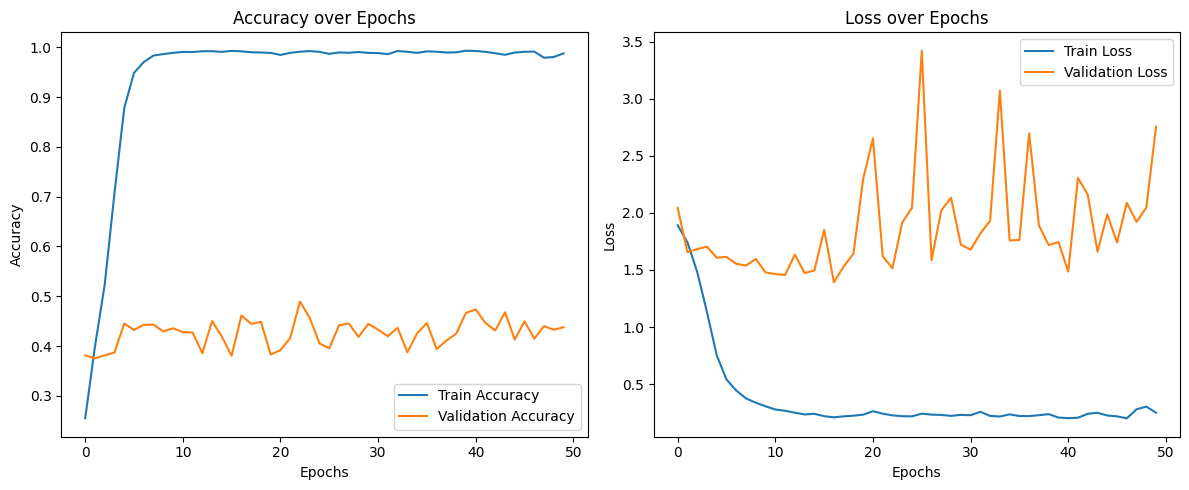

In [34]:
def plot_training_history(history):
    # Accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)
